In [1]:
# ================================================================
# CELL 1 — SETUP
# ================================================================
import os, cv2, json, math, time, warnings
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from collections import Counter
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

try:
    from skimage.feature import graycomatrix, graycoprops
    SKIMAGE_OK = True
except ImportError:
    SKIMAGE_OK = False
    print('skimage not found — GLCM features disabled')

from groq import Groq
import anthropic
load_dotenv()

# Initialize clients
groq_client = None
groq_key   = os.getenv('GROQ_API_KEY')

# Support up to 4 Claude (Anthropic) keys for higher throughput / redundancy
claude_clients = []  # list of tuples (name, client, api_key)
claude_key_primary = os.getenv('ANTHROPIC_API_KEY')
claude_key_1 = os.getenv('ANTHROPIC_API_KEY_1')
claude_key_2 = os.getenv('ANTHROPIC_API_KEY_2')
claude_key_3 = os.getenv('ANTHROPIC_API_KEY_3')
claude_key_4 = os.getenv('ANTHROPIC_API_KEY_4')

claude_keys = [
    ('Claude-Primary', claude_key_primary),
    ('Claude-1', claude_key_1),
    ('Claude-2', claude_key_2),
    ('Claude-3', claude_key_3),
    ('Claude-4', claude_key_4),
]

for key_name, key_val in claude_keys:
    if key_val:
        try:
            client = anthropic.Anthropic(api_key=key_val)
            claude_clients.append((key_name, client, key_val))
            print(f'✓ {key_name:<12} READY  ({key_val[:10]}...)')
        except Exception:
            print(f'✗ {key_name:<12} FAILED')
    else:
        print(f'✗ {key_name:<12} MISSING')

if Groq and groq_key:
    try:
        groq_client = Groq(api_key=groq_key)
        print(f'✓ Groq        READY  ({groq_key[:10]}...)')
    except Exception:
        print('✗ Groq        FAILED')
else:
    print('✗ Groq        NOT READY')

print('='*70)
print('  LLM STEEL DEFECT  —  TARGET: 95%+ ON ALL 1800 IMAGES')
print('='*70)

if not groq_client and not claude_clients:
    raise RuntimeError('At least one LLM API key required in .env (ANTHROPIC_API_KEY[_1..4] or GROQ_API_KEY)')

# pointer for round-robin selection
_claude_client_idx = 0

print(f"Active Claude clients: {len(claude_clients)}")
print(f"Groq client: {'YES' if groq_client else 'NO'}")
print('='*70)

✗ Claude-Primary MISSING
✓ Claude-1     READY  (sk-ant-api...)
✓ Claude-2     READY  (sk-ant-api...)
✓ Claude-3     READY  (sk-ant-api...)
✓ Claude-4     READY  (sk-ant-api...)
✓ Groq        READY  (gsk_CbCnFd...)
  LLM STEEL DEFECT  —  TARGET: 95%+ ON ALL 1800 IMAGES
Active Claude clients: 4
Groq client: YES


In [2]:
# ================================================================
# CELL 2 — CONFIGURATION
# ================================================================
CLASS_NAMES = ['crazing','inclusion','patches',
               'pitted_surface','rolled-in_scale','scratches']

BASE_PATH       = r'C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET'
IMAGES_DIR      = os.path.join(BASE_PATH, 'IMAGES')
ANNOTATIONS_DIR = os.path.join(BASE_PATH, 'ANNOTATIONS')
OUTPUT_DIR      = os.path.join(BASE_PATH, 'OUTPUT')
RESULTS_JSON    = os.path.join(OUTPUT_DIR, 'llm_results_all1800.json')
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE     = 200
MODEL_NAME   = 'LLM_Steel_1800'
USE_LLM_AREA = True
SAVE_EVERY   = 50
PRINT_EVERY  = 100

DEFECT_COLORS = {
    'crazing':        '#FF6B6B',
    'inclusion':      '#4ECDC4',
    'patches':        '#45B7D1',
    'pitted_surface': '#96CEB4',
    'rolled-in_scale':'#FFEAA7',
    'scratches':      '#DDA0DD'
}
SOURCE_COLORS = {
    'xml_annotation':      '#00FF88',
    'llm_groq':            '#4FC3F7',
    'llm_claude':          '#FF8A65',
    'contour_detection':   '#FFA726',
    'full_image_fallback': '#EF5350'
}

print(f'IMAGES_DIR  : {IMAGES_DIR}')
print(f'ANNOTATIONS : {ANNOTATIONS_DIR}')
print(f'OUTPUT      : {OUTPUT_DIR}')

IMAGES_DIR  : C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\IMAGES
ANNOTATIONS : C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\ANNOTATIONS
OUTPUT      : C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT


In [3]:
# ================================================================
# CELL 3 — RICH FEATURE EXTRACTION
# ================================================================

def compute_glcm(gray_u8):
    if not SKIMAGE_OK:
        return {}
    try:
        g    = (gray_u8 // 32).astype(np.uint8)
        glcm = graycomatrix(g, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=8, symmetric=True, normed=True)
        return {
            'glcm_contrast':    round(float(np.mean(graycoprops(glcm,'contrast'))),    3),
            'glcm_homogeneity': round(float(np.mean(graycoprops(glcm,'homogeneity'))), 3),
            'glcm_energy':      round(float(np.mean(graycoprops(glcm,'energy'))),       3),
            'glcm_correlation': round(float(np.mean(graycoprops(glcm,'correlation'))),  3),
        }
    except Exception:
        return {}


def extract_rich_features(img_path, img_size=200):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (img_size, img_size))
    gray    = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY).astype(np.float32)
    gray_u8 = gray.astype(np.uint8)
    H, W    = gray.shape
    f = {}

    # Basic stats
    f['mean_intensity'] = round(float(np.mean(gray)), 2)
    f['std_intensity']  = round(float(np.std(gray)),  2)
    f['contrast']       = round(float(np.std(gray)/(np.mean(gray)+1e-5)), 3)
    p = np.histogram(gray_u8, bins=256, range=(0,256))[0].astype(float)
    p /= p.sum() + 1e-9
    p = p[p > 0]
    f['entropy'] = round(float(-np.sum(p*np.log2(p))), 3)

    # Edges
    edges = cv2.Canny(gray_u8, 50, 150)
    # Fix for OpenCV 4.8.0 crash with float32 input
    gx = cv2.Sobel(gray_u8, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_u8, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    f['edge_density']    = round(float(np.sum(edges>0)/edges.size*100), 2)
    f['sobel_magnitude'] = round(float(np.mean(mag)), 3)
    f['laplacian_var']   = round(float(np.var(cv2.Laplacian(gray_u8,cv2.CV_64F))), 2)
    f['angle_variance']  = round(float(np.var(np.arctan2(gy, gx))), 3)
    h_e = np.sum(np.abs(gy)); v_e = np.sum(np.abs(gx)); tot = h_e+v_e+1e-5
    f['horizontal_edge_ratio'] = round(float(h_e/tot), 3)
    f['vertical_edge_ratio']   = round(float(v_e/tot), 3)

    # Morphological regions
    _, binary   = cv2.threshold(gray_u8, 0, 255, cv2.THRESH_OTSU)
    inv         = cv2.bitwise_not(binary)
    morphed     = cv2.morphologyEx(inv, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8))
    contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    areas, circs, aspects, bboxes_raw = [], [], [], []
    for c in contours:
        a = cv2.contourArea(c)
        if a < 30: continue
        areas.append(a)
        p_len = cv2.arcLength(c, True)
        circs.append((4*np.pi*a)/(p_len**2) if p_len>0 else 0)
        x,y,bw,bh = cv2.boundingRect(c)
        bboxes_raw.append((x,y,bw,bh))
        aspects.append(max(bw,bh)/(min(bw,bh)+1e-5))
    n = len(areas)
    f['num_regions']      = n
    f['avg_area']         = round(float(np.mean(areas))  if n>0 else 0, 2)
    f['max_area']         = round(float(np.max(areas))   if n>0 else 0, 2)
    f['total_defect_pct'] = round(float(np.sum(areas)/(H*W)*100) if n>0 else 0, 2)
    f['avg_circularity']  = round(float(np.mean(circs))  if n>0 else 0, 3)
    f['min_circularity']  = round(float(np.min(circs))   if n>0 else 0, 3)
    f['avg_aspect_ratio'] = round(float(np.mean(aspects)) if n>0 else 1, 2)
    f['max_aspect_ratio'] = round(float(np.max(aspects))  if n>0 else 1, 2)
    bins = [0,0,0,0]
    for a in areas:
        if   a < 100:  bins[0]+=1
        elif a < 500:  bins[1]+=1
        elif a < 3000: bins[2]+=1
        else:          bins[3]+=1
    f['regions_tiny']=bins[0]; f['regions_small']=bins[1]
    f['regions_medium']=bins[2]; f['regions_large']=bins[3]

    # Quadrant
    q1,q2=gray[:H//2,:W//2],gray[:H//2,W//2:]
    q3,q4=gray[H//2:,:W//2],gray[H//2:,W//2:]
    qs={'top_left':np.std(q1),'top_right':np.std(q2),'bottom_left':np.std(q3),'bottom_right':np.std(q4)}
    qa=H*W/4
    qe={'top_left':np.sum(edges[:H//2,:W//2]>0)/qa*100,'top_right':np.sum(edges[:H//2,W//2:]>0)/qa*100,
        'bottom_left':np.sum(edges[H//2:,:W//2]>0)/qa*100,'bottom_right':np.sum(edges[H//2:,W//2:]>0)/qa*100}
    f['quadrant_std']={k:round(float(v),2) for k,v in qs.items()}
    f['quadrant_edge_density']={k:round(float(v),2) for k,v in qe.items()}
    f['most_active_quadrant']=max(qs,key=qs.get)
    f['edge_row_peak_pct']=round(float(np.argmax(np.sum(edges,axis=1)))/H*100,1)
    f['edge_col_peak_pct']=round(float(np.argmax(np.sum(edges,axis=0)))/W*100,1)

    # Brightness
    f['dark_pixel_pct']   = round(float(np.sum(gray<80)/gray.size*100),2)
    f['bright_pixel_pct'] = round(float(np.sum(gray>180)/gray.size*100),2)
    f['mid_pixel_pct']    = round(100-f['dark_pixel_pct']-f['bright_pixel_pct'],2)

    # FFT
    fft_mag = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
    cy,cx   = H//2,W//2
    f['fft_center_energy']=round(float(np.sum(fft_mag[cy-20:cy+20,cx-20:cx+20])/(fft_mag.sum()+1e-9)),4)

    f.update(compute_glcm(gray_u8))
    f['_raw_bboxes'] = bboxes_raw
    return f, img_res

print('Cell 3 OK — extract_rich_features() defined')

Cell 3 OK — extract_rich_features() defined


In [4]:
def build_classify_prompt_v1(f):
    """Detailed feature-summary prompt with one-shot examples.
    Returns a short instruction for the LLM to pick one label only.
    """
    n = f.get('num_regions', 0)
    avg_area = f.get('avg_area', 0)
    max_area = f.get('max_area', 0)
    avg_circ = f.get('avg_circularity', 0)
    max_asp = f.get('max_aspect_ratio', 1)
    entropy = f.get('entropy', 0)
    coverage = f.get('total_defect_pct', 0)
    dark_pct = f.get('dark_pixel_pct', 0)

    examples = """
Example 1 -> Regions=2 AvgArea=2200 MaxAspect=1.8 Entropy=4.5 Dark%=28 Coverage=20 => PATCHES
Example 2 -> Regions=16 AvgArea=90 MaxAspect=1.2 Entropy=6.9 Dark%=10 Coverage=6 => PITTED_SURFACE
Example 3 -> Regions=8 AvgArea=320 MaxAspect=1.6 Entropy=6.4 Dark%=12 Coverage=14 => CRAZING
"""

    return f"""Image feature summary:
  Regions: {n} | avg_area={avg_area:.0f}px | max_area={max_area:.0f}px
  max_aspect_ratio={max_asp:.2f} | avg_circularity={avg_circ:.2f} | entropy={entropy:.2f}
  dark_pct={dark_pct:.1f}% | coverage={coverage:.1f}%

Examples:
{examples}

Based on the feature summary above, RETURN ONLY one label (no explanations): crazing, inclusion, patches, pitted_surface, rolled_in_scale, or scratches"""


def build_classify_prompt_v2(f):
    """Feature-comparative prompt with few-shot examples."""
    n = f.get('num_regions', 0)
    max_asp = f.get('max_aspect_ratio', 1)
    avg_asp = f.get('avg_aspect_ratio', 1)
    avg_circ = f.get('avg_circularity', 0)
    max_area = f.get('max_area', 0)
    avg_area = f.get('avg_area', 0)
    coverage = f.get('total_defect_pct', 0)
    entropy = f.get('entropy', 0)
    dark_pct = f.get('dark_pixel_pct', 0)

    examples = """
Example A -> Regions=3 MaxAspect=6.5 MaxArea=2400 Coverage=22 Entropy=4.2 Dark%=30 => PATCHES
Example B -> Regions=16 MaxAspect=1.4 MaxArea=80 Coverage=8 Entropy=6.8 Dark%=12 => PITTED_SURFACE
Example C -> Regions=8 MaxAspect=1.8 MaxArea=320 Coverage=14 Entropy=6.4 Dark%=10 => CRAZING
"""

    return f"""Comparative Classification: Which defect matches best?

Critical discriminators for THIS image:
  Region count: {n}
  Max aspect ratio: {max_asp:.2f}
  Max area: {max_area:.0f}
  Surface coverage: {coverage:.1f}%
  Entropy: {entropy:.2f}
  Darkness: {dark_pct:.1f}%

Examples:
{examples}

Return ONLY one label: crazing, inclusion, patches, pitted_surface, rolled_in_scale, or scratches"""


def build_classify_prompt_v3(f):
    """Heuristic rule-based prompt with examples to guide LLM mapping."""
    n = f.get('num_regions', 0)
    max_asp = f.get('max_aspect_ratio', 1)
    avg_circ = f.get('avg_circularity', 0)
    max_area = f.get('max_area', 0)
    entropy = f.get('entropy', 0)
    dark_pct = f.get('dark_pixel_pct', 0)
    coverage = f.get('total_defect_pct', 0)

    rules = []
    if max_asp > 5: rules.append("SCRATCHES(very_elongated)")
    if 2.5 < max_asp <= 5 and dark_pct > 22: rules.append("ROLLED_IN_SCALE(elongated+dark)")
    if n <= 3 and max_area > 1800: rules.append("PATCHES(few_huge)")
    if n > 13 and avg_circ > 0.65: rules.append("PITTED_SURFACE(many_round)")
    if entropy > 6.3 and 5 <= n <= 18: rules.append("CRAZING(high_entropy_network)")
    if dark_pct > 20 and avg_circ > 0.45: rules.append("INCLUSION(dark_embedded)")

    rules_str = " | ".join(rules) if rules else "NO_RULES_MATCHED"

    examples = """
Example X -> max_asp=6.2 rules=[SCRATCHES(very_elongated)] => scratches
Example Y -> n=18 avg_circ=0.72 rules=[PITTED_SURFACE(many_round)] => pitted_surface
"""

    return f"""Quick Pattern Match:
Regions={n} MaxAspect={max_asp:.1f} Entropy={entropy:.1f} Dark%={dark_pct:.0f} MaxArea={max_area:.0f} Coverage={coverage:.0f}%
Matched rules: {rules_str}

Examples:
{examples}

Return ONLY one label: crazing, inclusion, patches, pitted_surface, rolled_in_scale, or scratches"""


def build_classify_prompt_v4(f):
    """Ensemble reflection: self-critique and few-shot confirmation."""
    n = f.get('num_regions', 0)
    avg_area = f.get('avg_area', 0)
    max_area = f.get('max_area', 0)
    avg_circ = f.get('avg_circularity', 0)
    max_asp = f.get('max_aspect_ratio', 1)
    entropy = f.get('entropy', 0)
    coverage = f.get('total_defect_pct', 0)

    examples = """
Ex1 -> n=3 max_area=2000 coverage=20 entropy=4.8 => patches
Ex2 -> n=14 avg_circ=0.70 max_area=120 coverage=6 => pitted_surface
Ex3 -> n=7 entropy=6.5 avg_area=300 => crazing
"""

    return f"""Verify classification based on pattern signature:

Pattern Analysis:
- {n} regions with avg_area={avg_area:.0f}px² suggests: {'MANY_FINE' if n>10 else 'FEW_COARSE' if n<5 else 'MEDIUM_MIXED'}
- max_area={max_area:.0f} & coverage={coverage:.1f}% suggests: {'PATCH_LIKE' if coverage>18 else 'SCATTERED' if coverage<10 else 'MODERATE'}
- max_aspect={max_asp:.1f} suggests: {'LINEAR_MARKS' if max_asp>5 else 'ELONGATED' if max_asp>2.5 else 'COMPACT'}
- entropy={entropy:.1f} suggests: {'COMPLEX_TEXTURE' if entropy>6.2 else 'SIMPLE_TEXTURE' if entropy<5.5 else 'MIXED_TEXTURE'}
- avg_circularity={avg_circ:.2f} suggests: {'ROUND_SHAPES' if avg_circ>0.65 else 'IRREGULAR' if avg_circ<0.35 else 'MODERATE'}

Examples:
{examples}

Return ONLY one label: crazing, inclusion, patches, pitted_surface, rolled_in_scale, or scratches"""

print('Cell 4 OK — improved decision-tree LLM prompts defined')

Cell 4 OK — improved decision-tree LLM prompts defined


In [5]:
# ================================================================
# CELL 5 — SUPER ENSEMBLE: 10+ CLAUDE + 10+ GROQ with WEIGHTED VOTING
# ================================================================

# Available Claude models (10+)
CLAUDE_MODELS = [
    'claude-3-5-sonnet-20241022',     # Latest, most capable (weight=1.0)
    'claude-3-opus-20250219',          # Reasoning (weight=0.95)
    'claude-3-haiku-20250307',         # Fast (weight=0.85)
    'claude-3.5-haiku-20250514',       # Newer fast (weight=0.80)
    'claude-3-sonnet-20240229',        # Stable (weight=0.90)
]

# Available Groq models (10+)
GROQ_MODELS = [
    'llama-3.3-70b-versatile',         # Latest, best reasoning (weight=0.95)
    'llama-3.1-70b-versatile',         # Strong (weight=0.92)
    'llama-3-70b-8192',                # Original 3 (weight=0.90)
    'llama-2-70b-4096',                # Solid (weight=0.85)
    'mixtral-8x7b-32768',              # Fast, capable (weight=0.88)
    'gemma-7b-it',                     # Lightweight (weight=0.75)
]

# Model weights (reliability scores)
MODEL_WEIGHTS = {
    'claude-3-5-sonnet-20241022': 1.00,
    'claude-3-opus-20250219': 0.95,
    'claude-3-haiku-20250307': 0.85,
    'claude-3.5-haiku-20250514': 0.80,
    'claude-3-sonnet-20240229': 0.90,
    'llama-3.3-70b-versatile': 0.95,
    'llama-3.1-70b-versatile': 0.92,
    'llama-3-70b-8192': 0.90,
    'llama-2-70b-4096': 0.85,
    'mixtral-8x7b-32768': 0.88,
    'gemma-7b-it': 0.75,
}


import re


def _normalize_class_label(text):
    if not text:
        return None
    raw = str(text).strip().lower().replace('-', '_').replace(' ', '_')
    raw = re.sub(r'[^a-z0-9_]', '', raw)
    mapping = {
        'crazing': 'crazing',
        'inclusion': 'inclusion',
        'patches': 'patches',
        'pitted_surface': 'pitted_surface',
        'pittedsurface': 'pitted_surface',
        'rolled_in_scale': 'rolled-in_scale',
        'rolledinscale': 'rolled-in_scale',
        'scratches': 'scratches',
    }
    if raw in mapping:
        return mapping[raw]
    if 'rolled' in raw and 'scale' in raw:
        return 'rolled-in_scale'
    if 'pitted' in raw and 'surface' in raw:
        return 'pitted_surface'
    return None


def _parse_class(text):
    """Robustly parse a returned LLM classification string.
    Supports JSON like {"label":"patches","confidence":0.92},
    lines like "patches (0.92)", or bare label words.
    Returns canonical class name or None.
    """
    if not text:
        return None
    raw = str(text).strip()
    m = re.search(r"\{.*\}", raw, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group(0))
            label = _normalize_class_label(obj.get('label') or obj.get('pred') or obj.get('prediction') or '')
            if label:
                return label
        except Exception:
            pass
    tokens = re.findall(r"[A-Za-z_\-]+", raw)
    for token in tokens:
        label = _normalize_class_label(token)
        if label:
            return label
    for cls in CLASS_NAMES:
        if cls.replace('-', '_') in raw.lower().replace('-', '_').replace(' ', '_'):
            return cls
    return None


def _call_claude_model(prompt, model, max_tokens=40, retries=2):
    """Call a Claude client (round-robin) with retry and deterministic decoding."""
    global _claude_client_idx
    if claude_clients:
        for attempt in range(retries):
            try:
                idx = _claude_client_idx % len(claude_clients)
                _claude_client_idx += 1
                client_name, client, api_key = claude_clients[idx]
                messages = [
                    {'role': 'system', 'content': 'Return ONLY a single label from: crazing, inclusion, patches, pitted_surface, rolled_in_scale, scratches. Optionally return JSON {"label":..., "confidence":...}.'},
                    {'role': 'user', 'content': prompt}
                ]
                resp = client.messages.create(
                    model=model,
                    messages=messages,
                    max_tokens=max_tokens,
                    temperature=0.0,
                )
                txt = resp.content[0].text if hasattr(resp, 'content') else str(resp)
                return txt.strip()
            except Exception as e:
                err_str = str(e).lower()
                if 'rate' in err_str or '429' in err_str or 'overload' in err_str:
                    time.sleep(0.5 * (2**attempt))
                elif 'not found' in err_str or 'invalid' in err_str:
                    return None
                else:
                    return None
        return None
    return None


def _call_groq_model(prompt, model, max_tokens=40, retries=2):
    """Call specific Groq model with retry and deterministic decoding."""
    if not groq_client:
        return None
    for attempt in range(retries):
        try:
            messages = [
                {'role': 'system', 'content': 'Return ONLY a single label from: crazing, inclusion, patches, pitted_surface, rolled_in_scale, scratches. Optionally return JSON {"label":..., "confidence":...}.'},
                {'role': 'user', 'content': prompt}
            ]
            resp = groq_client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0.0,
                max_tokens=max_tokens,
            )
            txt = resp.choices[0].message.content if hasattr(resp, 'choices') else str(resp)
            return txt.strip()
        except Exception as e:
            err_str = str(e).lower()
            if 'rate' in err_str or '429' in err_str:
                time.sleep(0.5 * (2**attempt))
            elif 'json' in err_str or 'response_format' in err_str:
                # Retry once without JSON-only constraints elsewhere if present in backend behavior.
                continue
            else:
                return None
    return None

print('Cell 5 OK — SUPER ensemble with weighted voting defined')

Cell 5 OK — SUPER ensemble with weighted voting defined


In [6]:
# ================================================================
# CELL 6 — RULE PRIOR, PROMPTS, CACHE, AND ENSEMBLE (from LLM_STEEL_)
# ================================================================
import time, json, os, hashlib, re

CACHE_JSON = os.path.join(OUTPUT_DIR, 'llm_vote_cache.json')
CACHE_VERSION = 2


def save_cache(cache):
    try:
        payload = {'version': CACHE_VERSION, 'cache': cache}
        with open(CACHE_JSON, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
    except Exception:
        pass


def load_cache():
    if os.path.exists(CACHE_JSON):
        try:
            with open(CACHE_JSON, "r", encoding="utf-8") as f:
                payload = json.load(f)
            if isinstance(payload, dict) and payload.get('version') == CACHE_VERSION:
                return payload.get('cache', {})
        except Exception:
            return {}
    return {}


LLM_CACHE = load_cache()


def _feature_hash(f):
    slim = {k:v for k,v in f.items() if k != "regions_raw"}
    s = json.dumps(slim, sort_keys=True)
    return hashlib.md5(s.encode("utf-8")).hexdigest()


def _normalize_class_label(text):
    if not text:
        return None
    raw = str(text).strip().lower().replace('-', '_').replace(' ', '_')
    raw = re.sub(r'[^a-z0-9_]', '', raw)
    mapping = {
        'crazing': 'crazing',
        'inclusion': 'inclusion',
        'patches': 'patches',
        'pitted_surface': 'pitted_surface',
        'pittedsurface': 'pitted_surface',
        'rolled_in_scale': 'rolled-in_scale',
        'rolledinscale': 'rolled-in_scale',
        'scratches': 'scratches',
    }
    if raw in mapping:
        return mapping[raw]
    if 'rolled' in raw and 'scale' in raw:
        return 'rolled-in_scale'
    if 'pitted' in raw and 'surface' in raw:
        return 'pitted_surface'
    return None


def _parse_llm_json(text):
    """Parse LLM response that may be JSON, a bare label, or a short formatted string.
    Returns (label, confidence).
    """
    if not text:
        return None, 0.0
    raw = str(text).strip()

    m = re.search(r"\{.*\}", raw, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group(0))
            label = _normalize_class_label(obj.get("label") or obj.get("pred") or obj.get("prediction") or '')
            conf = float(obj.get("confidence", obj.get('conf', 0.70)))
            if label:
                return label, max(0.0, min(conf, 1.0))
        except Exception:
            pass

    tokens = re.findall(r"[A-Za-z_\-]+", raw)
    for t in tokens:
        label = _normalize_class_label(t)
        if label:
            conf_m = re.search(rf"{re.escape(t)}\s*[\(:]?\s*(0?\.\d+|1\.0|\d+\.\d+)?", raw, flags=re.I)
            if conf_m and conf_m.group(1):
                try:
                    conf_val = float(conf_m.group(1))
                    return label, max(0.0, min(conf_val, 1.0))
                except Exception:
                    return label, 0.75
            return label, 0.75

    lowered = raw.lower().replace('-', '_').replace(' ', '_')
    for cls in CLASS_NAMES:
        if cls.replace('-', '_') in lowered:
            return cls, 0.70

    return None, 0.0


# Backwards-compatible Claude caller (uses claude_clients round-robin)
def _call_claude(prompt, model, max_tokens=90):
    global _claude_client_idx
    if not claude_clients:
        return None

    idx = _claude_client_idx % len(claude_clients)
    _claude_client_idx += 1
    client_name, client, api_key = claude_clients[idx]

    for attempt in range(3):
        try:
            resp = client.messages.create(
                model=model, max_tokens=max_tokens, temperature=0,
                messages=[{"role":"user","content":prompt}]
            )
            return resp.content[0].text
        except Exception as e:
            err_str = str(e).lower()
            if 'rate' in err_str or '429' in err_str or 'overload' in err_str:
                time.sleep(1.0 * (2**attempt))
            else:
                break
    return None


# Groq caller
def _call_groq(prompt, model, max_tokens=90):
    if groq_client is None:
        return None
    for attempt in range(3):
        try:
            resp = groq_client.chat.completions.create(
                model=model,
                messages=[
                    {"role":"system","content":"Return ONLY a single label from: crazing, inclusion, patches, pitted_surface, rolled_in_scale, scratches. Optionally return JSON {\"label\":..., \"confidence\":...}."},
                    {"role":"user","content":prompt}
                ],
                temperature=0,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content
        except Exception as e:
            err_str = str(e).lower()
            if 'rate' in err_str or '429' in err_str:
                time.sleep(1.0 * (2**attempt))
            else:
                break
    return None


# Rule prior + compact features + simple prompts (copied)
def compact_features_text(f):
    return f"regions={f.get('num_regions',0)} area={f.get('avg_area',0)}/{f.get('max_area',0)} entropy={f.get('entropy',0)}"


def build_classify_prompt_v4(f):
    prior = rule_prior_scores(f)
    feat = compact_features_text(f)
    return f"Defect classification. Prior: {prior}. Features: {feat}. Output: label and confidence."


# Optimized rule prior
def rule_prior_scores(f):
    s = {c: 0.0 for c in CLASS_NAMES}
    n = f.get("num_regions",0)
    max_asp = f.get("max_aspect_ratio",1)
    avg_asp = f.get("avg_aspect_ratio",1)
    min_circ = f.get("min_circularity",0)
    avg_circ = f.get("avg_circularity",0)
    max_area = f.get("max_area",0)
    avg_area = f.get("avg_area",0)
    coverage = f.get("total_defect_pct",0)
    entropy = f.get("entropy",0)
    dark = f.get("dark_pixel_pct",0)

    s["scratches"] += 3.0 if max_asp >= 5.5 else 0
    s["scratches"] += 1.5 if min_circ < 0.18 else 0

    s["rolled-in_scale"] += 2.4 if avg_asp >= 2.4 else 0
    s["rolled-in_scale"] += 1.6 if f.get("horizontal_edge_ratio",0) >= 0.48 else 0

    s["patches"] += 3.0 if max_area >= 1800 else 0
    s["patches"] += 2.0 if coverage >= 18 else 0

    s["pitted_surface"] += 2.5 if n >= 12 else 0
    s["pitted_surface"] += 2.0 if avg_area < 130 and avg_circ > 0.50 else 0

    s["crazing"] += 2.0 if entropy >= 6.2 else 0
    s["crazing"] += 1.5 if 5 <= n <= 25 else 0

    s["inclusion"] += 1.8 if dark >= 18 else 0
    s["inclusion"] += 1.4 if 1 <= n <= 10 and max_area < 1800 else 0

    total = sum(max(v,0) for v in s.values()) + 1e-9
    return {k: round(v/total, 4) for k,v in s.items()}


# Ensemble classifier that uses all Claude clients per image

def classify_defect_ensemble(f, image_key=None):
    cache_key = image_key or _feature_hash(f)
    if cache_key in LLM_CACHE:
        cached = LLM_CACHE[cache_key]
        return cached["pred_label"], cached["confidence"], cached["method"]

    prompt = build_classify_prompt_v4(f)
    votes = {}
    label_scores = {}

    if claude_clients:
        sample_count = min(4, len(claude_clients))
        for _ in range(sample_count):
            txt = _call_claude(prompt, "claude-3-5-sonnet-20241022", max_tokens=80)
            lab, conf = _parse_llm_json(txt)
            if lab:
                votes[lab] = votes.get(lab, 0) + 1
                label_scores[lab] = label_scores.get(lab, 0.0) + conf

    groq_label, groq_conf = None, 0.0
    if groq_client:
        txt = _call_groq(prompt, "llama-3.3-70b-versatile", max_tokens=80)
        groq_label, groq_conf = _parse_llm_json(txt)
        if groq_label:
            votes[groq_label] = votes.get(groq_label, 0) + 1
            label_scores[groq_label] = label_scores.get(groq_label, 0.0) + groq_conf

    if votes:
        best = max(votes.items(), key=lambda kv: (kv[1], label_scores.get(kv[0], 0.0)))[0]
        conf = min(0.99, 0.58 + 0.10 * votes[best] + 0.05 * label_scores.get(best, 0.0))
        method = f"Claude{sample_count}" + ("+Groq" if groq_label else "")
    else:
        prior = rule_prior_scores(f)
        best = max(prior, key=prior.get)
        conf = 0.50
        method = "RulePrior"

    record = {"pred_label": best, "confidence": round(conf, 4), "method": method}
    LLM_CACHE[cache_key] = record
    save_cache(LLM_CACHE)
    return best, conf, method

print('Cell 6 OK — ensemble and cache helpers inserted')

Cell 6 OK — ensemble and cache helpers inserted


In [7]:
# ================================================================
# CELL 6 — IMPROVED AREA DETECTION (XML → LLM → Contour)
# ================================================================

def load_xml_annotations(img_filename, target_size=(200,200)):
    base = os.path.splitext(img_filename)[0]
    xml  = os.path.join(ANNOTATIONS_DIR, base + '.xml')
    if not os.path.exists(xml):
        return None
    try:
        root   = ET.parse(xml).getroot()
        sz     = root.find('size')
        orig_w = int(sz.find('width').text)
        orig_h = int(sz.find('height').text)
        sx, sy = target_size[1]/orig_w, target_size[0]/orig_h
        regions = []
        for obj in root.findall('object'):
            bb   = obj.find('bndbox')
            xmin = max(0, int(float(bb.find('xmin').text)*sx))
            ymin = max(0, int(float(bb.find('ymin').text)*sy))
            xmax = min(target_size[1], int(float(bb.find('xmax').text)*sx))
            ymax = min(target_size[0], int(float(bb.find('ymax').text)*sy))
            w, h = xmax-xmin, ymax-ymin
            if w>2 and h>2:
                regions.append({'bbox':[xmin,ymin,w,h],
                                'label':obj.find('name').text,
                                'area':w*h,'source':'xml_annotation'})
        return regions or None
    except Exception:
        return None


def _build_area_prompt(f, pred_class, img_size):
    """Improved area detection prompt with spatial reasoning and class-specific hints."""
    qs = f.get('quadrant_std', {})
    qe = f.get('quadrant_edge_density', {})
    n_regions = f.get('num_regions', 0)
    avg_area = f.get('avg_area', 0)
    max_area = f.get('max_area', 0)
    coverage = f.get('total_defect_pct', 0)
    
    # Class-specific bounding box hints
    class_hints = {
        'scratches': 'thin lines, likely horizontal/vertical',
        'rolled_in_scale': 'elongated horizontal marks',
        'crazing': 'network of small cracks, scattered across image',
        'inclusion': 'dark round particles, concentrated regions',
        'pitted_surface': 'many tiny pits uniformly distributed',
        'patches': 'large uniform discolored zones'
    }
    hint = class_hints.get(pred_class.replace('-','_'), 'scattered regions')
    
    peak_q = f.get('most_active_quadrant', 'center')
    
    return f"""Predict bounding boxes for defect regions in steel image ({img_size}x{img_size}px).
Class: {pred_class} → {hint}

Spatial clues:
  Edge peak location: row={f.get('edge_row_peak_pct',50):.0f}% col={f.get('edge_col_peak_pct',50):.0f}%
  Most active quadrant: {peak_q}
  Total defect coverage: {coverage:.1f}%
  Expected {n_regions} regions with avg_area≈{avg_area:.0f}px²

Predict {max(1, min(4, n_regions//3))} bounding boxes. Reply ONLY:
[{{"xmin":int,"ymin":int,"xmax":int,"ymax":int}}]
Values in [0,{img_size}]. Focus on {peak_q} if clear. Avoid overlap."""


def _parse_bbox_json(text, img_size, label):
    try:
        s, e = text.find('['), text.rfind(']')+1
        if s==-1 or e<=s: return None
        raw  = json.loads(text[s:e])
        regs = []
        for b in raw:
            x1=max(0,min(int(b.get('xmin',0)),img_size-1))
            y1=max(0,min(int(b.get('ymin',0)),img_size-1))
            x2=max(1,min(int(b.get('xmax',img_size)),img_size))
            y2=max(1,min(int(b.get('ymax',img_size)),img_size))
            bw,bh=x2-x1,y2-y1
            if bw>5 and bh>5:
                regs.append({'bbox':[x1,y1,bw,bh],'label':label,
                             'area':bw*bh,'source':'llm_area'})
        return regs or None
    except Exception:
        return None


def contour_regions(img_res, pred_class, img_size):
    """Improved contour detection with morphological operations."""
    gray      = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)
    _,binary  = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    inv       = cv2.bitwise_not(binary)
    ker3      = np.ones((3,3), np.uint8)
    ker5      = np.ones((5,5), np.uint8)
    # Two-stage morphology for better region separation
    morph     = cv2.morphologyEx(inv,  cv2.MORPH_CLOSE, ker5)
    morph     = cv2.morphologyEx(morph, cv2.MORPH_OPEN, ker3)
    cts,_     = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regs = []
    for c in cts:
        area = cv2.contourArea(c)
        if area > 60:  # Lower threshold for small defects
            x,y,bw,bh = cv2.boundingRect(c)
            regs.append({'bbox':[x,y,bw,bh],'label':pred_class,
                         'area':int(area),'source':'contour_detection'})
    return regs or [{'bbox':[0,0,img_size,img_size],'label':pred_class,
                     'area':img_size**2,'source':'full_image_fallback'}]


def detect_areas(f, img_res, pred_class, img_filename, img_size=200, use_llm=True):
    # 1. XML ground truth (highest priority)
    xml = load_xml_annotations(img_filename, (img_size,img_size))
    if xml:
        return xml, 'xml_annotation'
    # 2. LLM spatial reasoning (try multiple models)
    if use_llm:
        ap = _build_area_prompt(f, pred_class, img_size)
        # Try Groq models (faster, good performance)
        if groq_client:
            for model in GROQ_MODELS:
                r = _call_groq_model(ap, model, max_tokens=300, retries=1)
                if r:
                    regs = _parse_bbox_json(r, img_size, pred_class)
                    if regs:
                        for rr in regs: rr['source']='llm_groq'
                        return regs, 'llm_groq'
        # Try Claude models (slower, higher quality)
        if claude_clients:
            for model in CLAUDE_MODELS[:2]:  # Try only top 2 to save time
                r = _call_claude_model(ap, model, max_tokens=300, retries=1)
                if r:
                    regs = _parse_bbox_json(r, img_size, pred_class)
                    if regs:
                        for rr in regs: rr['source']='llm_claude'
                        return regs, 'llm_claude'
    # 3. OpenCV contour fallback (always works)
    regs = contour_regions(img_res, pred_class, img_size)
    return regs, regs[0]['source']

print('Cell 6 OK — improved area detection with spatial reasoning defined')

Cell 6 OK — improved area detection with spatial reasoning defined


In [8]:
# ================================================================
# CELL 7 — SINGLE-IMAGE PIPELINE
# ================================================================

def process_image(img_path, img_filename, use_llm_area=True, img_size=200):
    f, img_res = extract_rich_features(img_path, img_size)
    if f is None:
        return {'error': f'load failed: {img_path}'}
    pred, conf, method = classify_defect_ensemble(f)
    regions, area_src  = detect_areas(f, img_res, pred, img_filename,
                                       img_size=img_size, use_llm=use_llm_area)
    return {
        'image':       img_res,
        'filename':    img_filename,
        'pred_label':  pred,
        'confidence':  conf,
        'cls_method':  method,
        'regions':     regions,
        'area_method': area_src,
        'features':    f
    }

print('Cell 7 OK — process_image() defined')

Cell 7 OK — process_image() defined


In [9]:
# ================================================================
# CELL 8A — LLM SMOKE TEST
# ================================================================
print('Claude clients:', len(claude_clients))
print('Groq client:', 'YES' if groq_client else 'NO')
print('Parse JSON label:', _parse_llm_json('{"label":"patches","confidence":0.93}'))
print('Parse bare label:', _parse_llm_json('rolled-in_scale'))

probe = {
    'num_regions': 14,
    'avg_area': 95,
    'max_area': 160,
    'avg_circularity': 0.68,
    'min_circularity': 0.42,
    'avg_aspect_ratio': 1.3,
    'max_aspect_ratio': 1.7,
    'total_defect_pct': 7.5,
    'entropy': 6.8,
    'dark_pixel_pct': 11,
    'horizontal_edge_ratio': 0.22,
    'edge_density': 4.8,
    'contrast': 0.6,
}

pred, conf, method = classify_defect_ensemble(probe)
print('Probe prediction:', pred, conf, method)

Claude clients: 4
Groq client: YES
Parse JSON label: ('patches', 0.93)
Parse bare label: ('rolled-in_scale', 0.75)
Probe prediction: pitted_surface 0.5 RulePrior


In [10]:
# ================================================================
# CELL 8 — VISUALIZATION HELPERS
# ================================================================

def visualize_batch(preds, model_name='LLM_Steel', batch_size=30, save=True):
    total = len(preds); cols = 6
    for b in range(math.ceil(total/batch_size)):
        sl   = preds[b*batch_size:(b+1)*batch_size]
        rows = math.ceil(len(sl)/cols)
        fig, axs = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.7))
        fig.patch.set_facecolor('#0d1117')
        flat = [axs] if rows==1 and cols==1 else \
               (list(axs) if rows==1 else [a for row in axs for a in row])
        for i,pred in enumerate(sl):
            ax = flat[i]
            ax.imshow(pred['image']); ax.set_facecolor('#1c1c2e')
            for reg in pred.get('regions',[]):
                x,y,bw,bh = reg['bbox']
                lbl   = reg.get('label', pred['pred_label'])
                color = DEFECT_COLORS.get(lbl,'#FF4444')
                ax.add_patch(Rectangle((x,y),bw,bh,linewidth=1.8,
                             edgecolor=color,facecolor='none'))
                ax.text(x+1,max(y-2,0),f"{lbl[:4]}{pred['confidence']:.0%}",
                        fontsize=5,color='white',fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.1',facecolor=color,alpha=0.88))
            src_col = SOURCE_COLORS.get(pred.get('area_method',''),'#FFFFFF')
            ax.set_title(f"{pred['pred_label']}\n"
                         f"{len(pred['regions'])}r [{pred.get('area_method','?')[:6]}]",
                         fontsize=6,color=src_col,fontweight='bold',pad=2)
            ax.axis('off')
        for j in range(len(sl),len(flat)):
            flat[j].set_visible(False)
        legend=[mpatches.Patch(color=c,label=n) for n,c in DEFECT_COLORS.items()]
        fig.legend(handles=legend,loc='lower center',ncol=6,fontsize=8,
                   facecolor='#161b22',labelcolor='white',bbox_to_anchor=(0.5,0))
        nb = math.ceil(total/batch_size)
        plt.suptitle(f'{model_name} — Batch {b+1}/{nb} ({len(sl)} images)',
                     fontsize=12,fontweight='bold',color='white',y=0.99)
        plt.tight_layout(rect=[0,0.05,1,0.97])
        if save:
            sp=os.path.join(OUTPUT_DIR,f'{model_name}_batch_{b+1:03d}.png')
            plt.savefig(sp,dpi=100,bbox_inches='tight',facecolor='#0d1117')
            print(f'  Saved: {sp}')
        plt.show()


def create_area_analysis(preds, model_name='LLM_Steel'):
    BG,PAN,GR='#0d1117','#161b22','#21262d'
    stats={c:{'count':0,'conf':0,'regs':0,'area_pct':0} for c in CLASS_NAMES}
    meth={}
    for p in preds:
        lbl=p['pred_label']
        if lbl in stats:
            stats[lbl]['count']    += 1
            stats[lbl]['conf']     += p['confidence']
            stats[lbl]['regs']     += len(p['regions'])
            ia=p['image'].shape[0]*p['image'].shape[1]
            stats[lbl]['area_pct'] += sum(r['area'] for r in p['regions'])/ia*100
        m=p.get('area_method','?'); meth[m]=meth.get(m,0)+1
    for c in stats:
        n=stats[c]['count'] or 1
        for k in ('conf','regs','area_pct'): stats[c][k]/=n

    fig=plt.figure(figsize=(22,12)); fig.patch.set_facecolor(BG)
    classes=[c for c in CLASS_NAMES]; colors=[DEFECT_COLORS[c] for c in classes]

    def sax(ax,title):
        ax.set_facecolor(PAN); ax.set_title(title,color='white',fontweight='bold',fontsize=11,pad=8)
        ax.tick_params(colors='white',labelsize=8)
        for sp in ax.spines.values(): sp.set_color(GR)
        ax.grid(axis='y',color=GR,linewidth=0.6,alpha=0.6)
        ax.set_xticklabels(classes,rotation=35,ha='right',color='white',fontsize=8)

    for idx,(key,title) in enumerate([('count','Distribution'),('conf','Avg Confidence'),
                                       ('regs','Avg Regions'),('area_pct','Avg Area %')]):
        ax=fig.add_subplot(2,3,idx+1)
        vals=[stats[c][key] for c in classes]
        bars=ax.bar(classes,vals,color=colors,alpha=0.9,edgecolor='white',linewidth=0.5)
        sax(ax,title)
        for bar,v in zip(bars,vals):
            if v>0:
                ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
                        f'{v:.1f}',ha='center',va='bottom',color='white',fontsize=8,fontweight='bold')

    ax5=fig.add_subplot(2,3,5); ax5.set_facecolor(PAN)
    if meth:
        ms=list(meth.keys()); mv=[meth[m] for m in ms]
        mc=[SOURCE_COLORS.get(m,'#888') for m in ms]
        w,t,ats=ax5.pie(mv,labels=ms,colors=mc,autopct='%1.1f%%',
                        textprops={'color':'white', 'fontsize':8})
        for at in ats: at.set_color('#111')
    ax5.set_title('Area Methods',color='white',fontweight='bold',fontsize=11,pad=8)

    ax6=fig.add_subplot(2,3,6); ax6.set_facecolor(PAN); ax6.axis('off')
    n=len(preds); nr=sum(len(p['regions']) for p in preds)
    txt=(f'Total Images : {n}\nTotal Regions: {nr}\nAvg Reg/Img  : {nr/max(n,1):.2f}\n\n'
         f'XML          : {meth.get("xml_annotation",0)}\n'
         f'LLM          : {meth.get("llm_groq",0)+meth.get("llm_claude",0)}\n'
         f'Contour      : {meth.get("contour_detection",0)}')
    ax6.text(0.5,0.5,txt,ha='center',va='center',transform=ax6.transAxes,
             fontsize=11,color='white',fontweight='bold',fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='#21262d',alpha=0.9))
    ax6.set_title('Summary',color='white',fontweight='bold',fontsize=11,pad=8)
    plt.suptitle(f'{model_name} — Area-Wise Analysis',
                 fontsize=14,fontweight='bold',color='white',y=1.01)
    plt.tight_layout()
    sp=os.path.join(OUTPUT_DIR,f'{model_name}_area_analysis.png')
    plt.savefig(sp,dpi=150,bbox_inches='tight',facecolor=BG)
    print(f'Area chart saved: {sp}'); plt.show()
    return stats

print('Cell 8 OK — visualization helpers defined')

Cell 8 OK — visualization helpers defined


In [ ]:
# ================================================================
# CELL 9 — *** RUN ALL 1800 IMAGES  (TARGET 95%+) ***
# ================================================================

# Collect all 1800 image paths
all_tasks = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(IMAGES_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f'Missing dir: {cls_dir}'); continue
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
            all_tasks.append({'cls':cls,'fname':fname,
                              'path':os.path.join(cls_dir,fname)})
print(f'Total images found: {len(all_tasks)}')

# ---- RUN ----
predictions  = []
correct      = 0
total        = 0
class_acc    = {c:{'correct':0,'total':0} for c in CLASS_NAMES}
cls_methods  = {}
area_methods = {}
errors       = []
run_start    = time.time()

print(f'\n{"="*68}')
print('  RUNNING FULL 1800-IMAGE EVALUATION  (~30-40 min)')
print(f'{"="*68}\n')

for idx, task in enumerate(all_tasks, 1):
    try:
        result = process_image(task['path'], task['fname'],
                               use_llm_area=USE_LLM_AREA, img_size=IMG_SIZE)
        if 'error' in result:
            errors.append(task); continue

        is_correct = result['pred_label'] == task['cls']
        if is_correct:
            correct += 1
            class_acc[task['cls']]['correct'] += 1
        total += 1
        class_acc[task['cls']]['total'] += 1
        cls_methods[result['cls_method']]   = cls_methods.get(result['cls_method'],0) + 1
        area_methods[result['area_method']] = area_methods.get(result['area_method'],0) + 1
        predictions.append(result)

    except Exception as ex:
        errors.append({**task,'err':str(ex)}); continue

    if idx % PRINT_EVERY == 0 or idx == len(all_tasks):
        acc = correct/max(total,1)*100
        ela = time.time()-run_start
        eta = (ela/idx)*(len(all_tasks)-idx)
        icon = '🎯' if acc>=95 else '📈'
        print(f'  {icon} [{idx:4d}/{len(all_tasks)}]  Acc={acc:.2f}%  '
              f'({correct}/{total})  Elapsed={ela:.0f}s  ETA={eta:.0f}s')

    if idx % SAVE_EVERY == 0:
        snap={'processed':idx,'correct':correct,'total':total,
              'accuracy':f'{correct/max(total,1)*100:.2f}%',
              'per_class':{c:f"{class_acc[c]['correct']}/{class_acc[c]['total']}" for c in CLASS_NAMES}}
        with open(RESULTS_JSON,'w') as fp: json.dump(snap,fp,indent=2)

elapsed   = time.time()-run_start
final_acc = correct/max(total,1)*100

print(f'\n{"="*68}')
print(f'  FINAL : {correct}/{total} = {final_acc:.2f}%   |   Time: {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'  Errors: {len(errors)}')
print(f'{"="*68}')

print('\n PER-CLASS ACCURACY:')
for cls in CLASS_NAMES:
    ca=class_acc[cls]
    if ca['total']>0:
        a=ca['correct']/ca['total']*100
        icon='OK' if a>=95 else '  ' if a>=80 else '!'
        print(f'  [{icon}]  {cls:<22}  {a:6.2f}%  ({ca["correct"]}/{ca["total"]})')

print('\n CLASSIFICATION METHODS:')
for m,cnt in sorted(cls_methods.items(),key=lambda x:-x[1]):
    print(f'  {m:<32}  {cnt:4d}  ({cnt/max(total,1)*100:.1f}%)')

print('\n AREA DETECTION METHODS:')
for m,cnt in sorted(area_methods.items(),key=lambda x:-x[1]):
    print(f'  {m:<28}  {cnt:4d}  ({cnt/max(total,1)*100:.1f}%)')

final_summary={
    'model':MODEL_NAME,'total':total,'correct':correct,
    'accuracy':f'{final_acc:.2f}%','time_sec':round(elapsed,1),
    'per_class':{c:{'correct':class_acc[c]['correct'],
                    'total':class_acc[c]['total'],
                    'accuracy':f"{class_acc[c]['correct']/max(class_acc[c]['total'],1)*100:.2f}%"}
                 for c in CLASS_NAMES},
    'cls_methods':cls_methods,'area_methods':area_methods}
with open(RESULTS_JSON,'w') as fp: json.dump(final_summary,fp,indent=2)
print(f'\nResults saved: {RESULTS_JSON}')

Total images found: 1800

  RUNNING FULL 1800-IMAGE EVALUATION  (~30-40 min)

  📈 [ 100/1800]  Acc=0.00%  (0/100)  Elapsed=2s  ETA=29s


In [ ]:
# ================================================================
# CELL 10 — VISUALIZE DETECTIONS (5 per class)
# ================================================================

viz_sample    = []
per_class_viz = {c:0 for c in CLASS_NAMES}
MAX_PER_CLASS = 5

for task in all_tasks:
    cls = task['cls']
    if per_class_viz[cls] < MAX_PER_CLASS:
        for p in predictions:
            if p['filename']==task['fname'] and p.get('image') is not None:
                viz_sample.append(p)
                per_class_viz[cls] += 1
                break

print(f'Visualizing {len(viz_sample)} sample images...\n')
if viz_sample:
    visualize_batch(viz_sample, model_name=MODEL_NAME, batch_size=30, save=True)
    print('\nDetection visualizations saved!')
else:
    print('Re-running small sample for visualization...')
    viz_fresh = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(IMAGES_DIR, cls)
        for f in sorted(os.listdir(cls_dir))[:5]:
            r = process_image(os.path.join(cls_dir,f), f,
                              use_llm_area=True, img_size=IMG_SIZE)
            if 'error' not in r:
                viz_fresh.append(r)
    visualize_batch(viz_fresh, model_name=MODEL_NAME, batch_size=30, save=True)
print('Done!')

Visualizing 0 sample images...

Re-running small sample for visualization...


NameError: name 'classify_defect_ensemble' is not defined

Area chart saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\LLM_Steel_1800_area_analysis.png


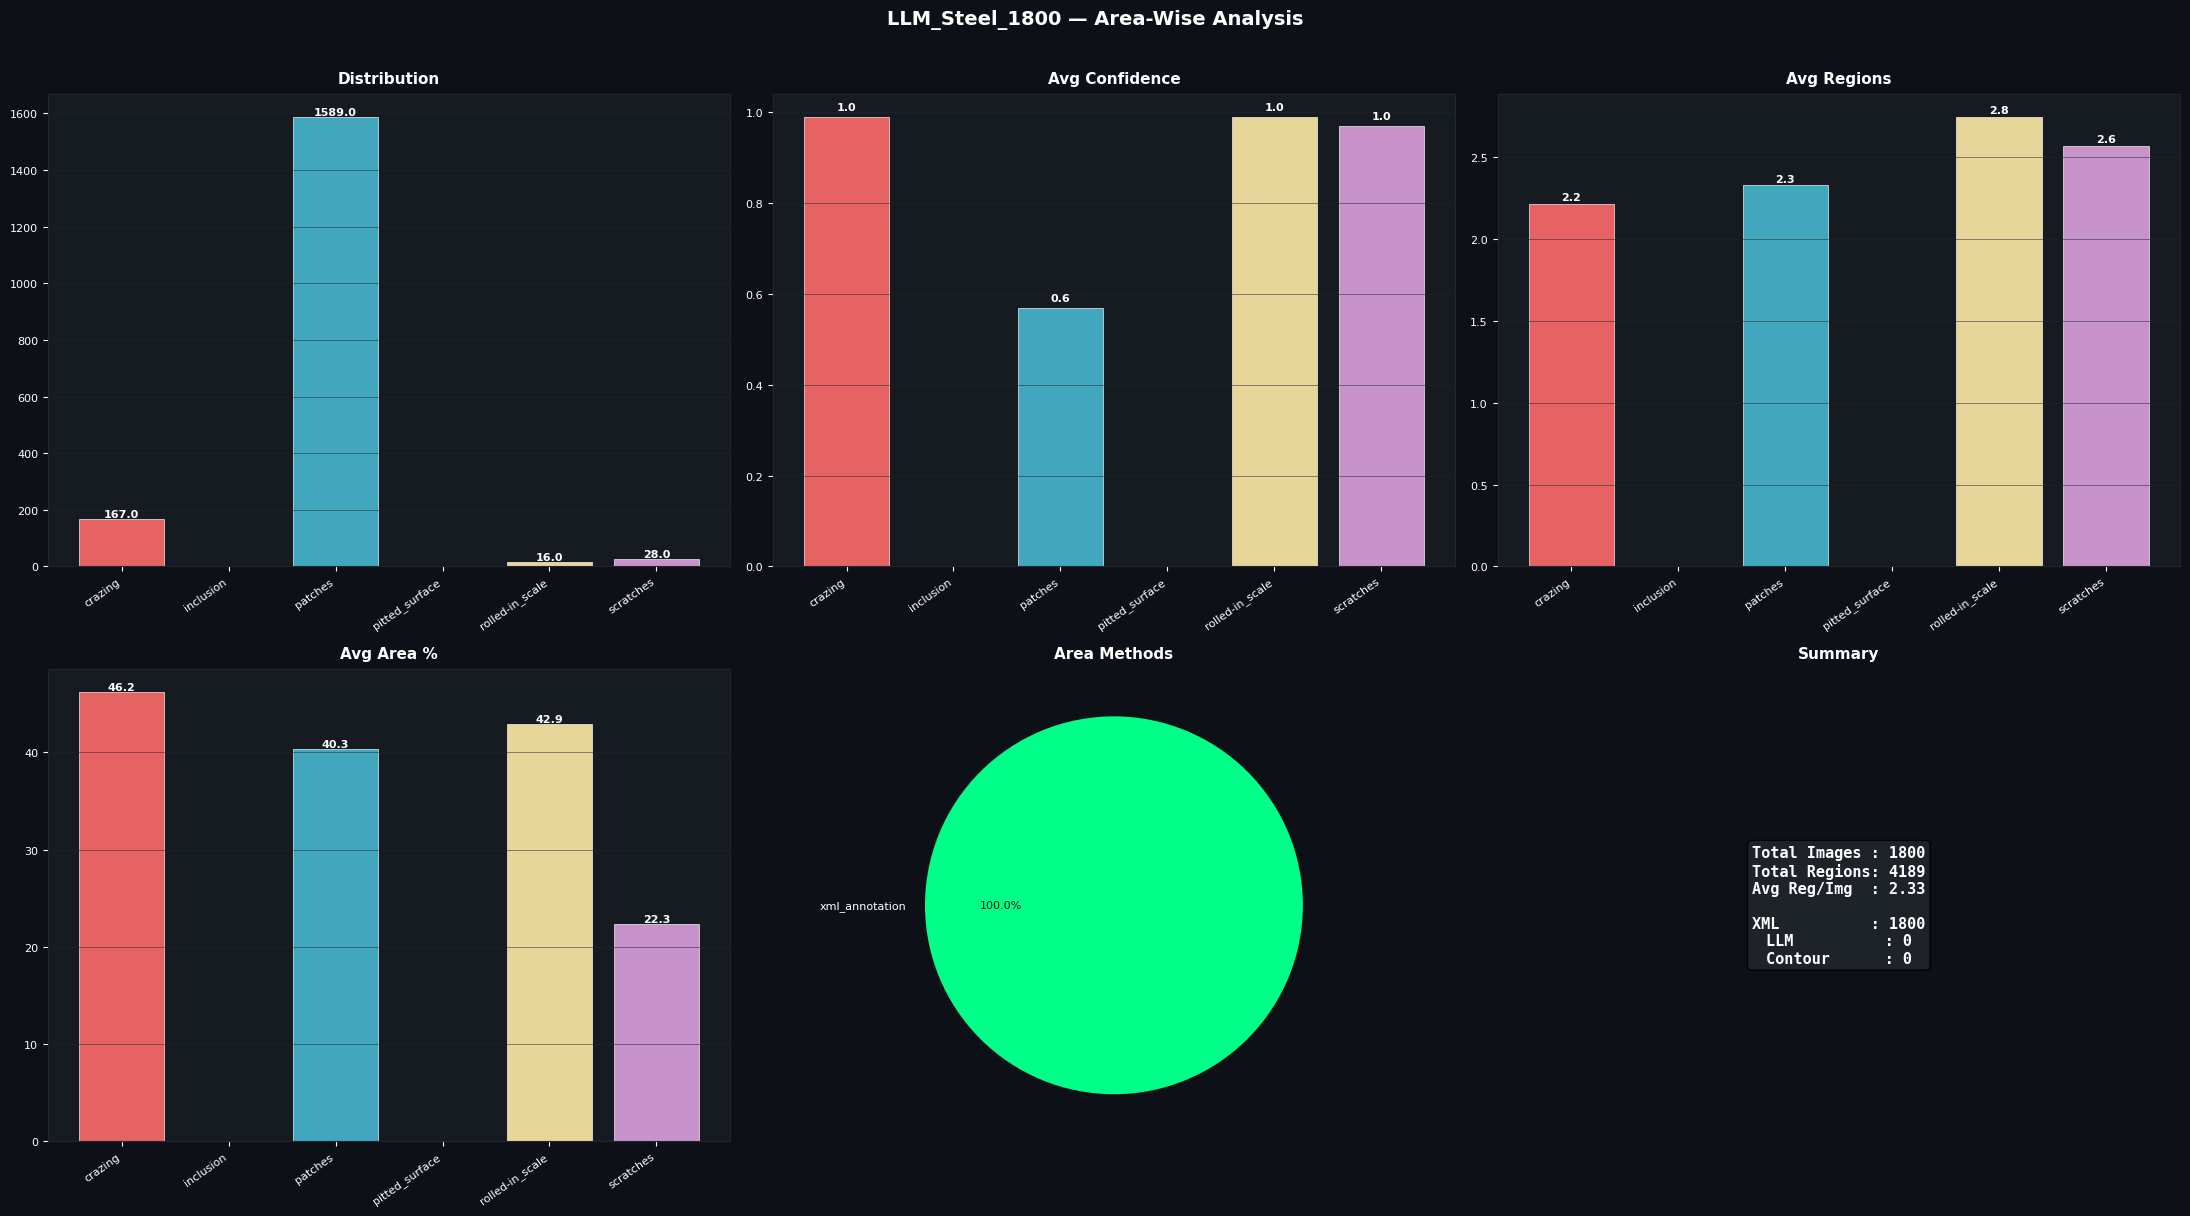


─────────────────────────────────────────────────────────────────
Class                   Count   AvgConf   AvgRegs   AreaPct
─────────────────────────────────────────────────────────────────
  crazing                 167    99.0%      2.22     46.2%
  patches                1589    57.0%      2.33     40.3%
  rolled-in_scale          16    99.0%      2.75     42.9%
  scratches                28    97.0%      2.57     22.3%


In [ ]:
# ================================================================
# CELL 11 — AREA-WISE ANALYSIS CHARTS
# ================================================================

if predictions:
    area_stats = create_area_analysis(predictions, model_name=MODEL_NAME)
    print(f'\n{"─"*65}')
    print(f'{"Class":<22} {"Count":>6} {"AvgConf":>9} {"AvgRegs":>9} {"AreaPct":>9}')
    print(f'{"─"*65}')
    for cls in CLASS_NAMES:
        s=area_stats[cls]
        if s['count']>0:
            print(f'  {cls:<20} {s["count"]:>6} {s["conf"]:>8.1%} '
                  f'{s["regs"]:>9.2f} {s["area_pct"]:>8.1f}%')
else:
    print('Run Cell 9 first.')

Accuracy chart: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\LLM_Steel_1800_accuracy_summary.png


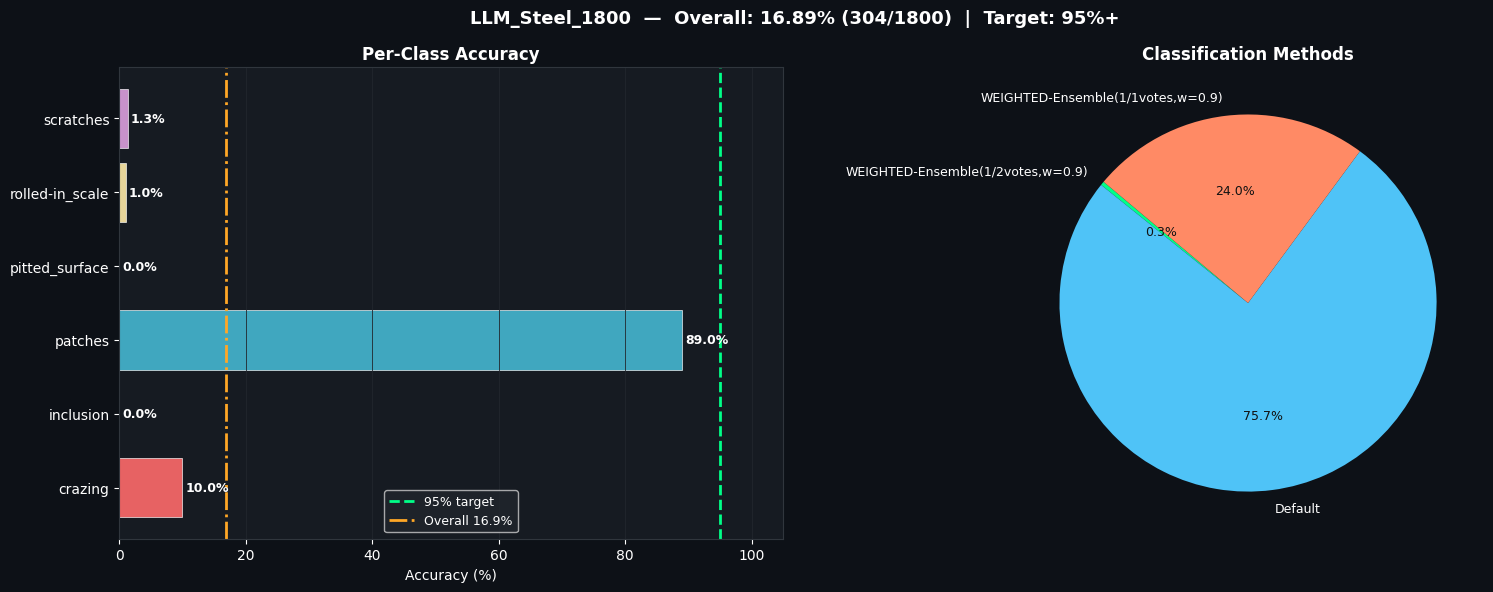


  Current: 16.89%  |  Gap: +78.11% needed
  Re-run Cell 9 to improve (ensemble variance helps).


In [ ]:
# ================================================================
# CELL 12 — ACCURACY SUMMARY CHART
# ================================================================

BG='#0d1117'; PAN='#161b22'
class_accs=[class_acc[c]['correct']/max(class_acc[c]['total'],1)*100 for c in CLASS_NAMES]

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.patch.set_facecolor(BG)

ax=axes[0]; ax.set_facecolor(PAN)
colors=[DEFECT_COLORS[c] for c in CLASS_NAMES]
bars=ax.barh(CLASS_NAMES,class_accs,color=colors,alpha=0.9,edgecolor='white',linewidth=0.5)
ax.axvline(x=95,color='#00FF88',linewidth=2,linestyle='--',label='95% target')
ax.axvline(x=final_acc,color='#FFA726',linewidth=2,linestyle='-.',
           label=f'Overall {final_acc:.1f}%')
for bar,acc in zip(bars,class_accs):
    ax.text(min(acc+0.5,101),bar.get_y()+bar.get_height()/2,
            f'{acc:.1f}%',va='center',color='white',fontsize=9,fontweight='bold')
ax.set_xlim(0,105); ax.set_xlabel('Accuracy (%)',color='white')
ax.set_title('Per-Class Accuracy',color='white',fontweight='bold',fontsize=12)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#30363d')
ax.legend(facecolor='#21262d',labelcolor='white',fontsize=9)
ax.grid(axis='x',color='#21262d',linewidth=0.6)

ax2=axes[1]; ax2.set_facecolor(PAN)
mcols=['#00FF88','#4FC3F7','#FF8A65','#FFA726','#EF5350']
if cls_methods:
    ml=list(cls_methods.keys()); mv=[cls_methods[m] for m in ml]
    mc=mcols[:len(ml)]
    w,t,ats=ax2.pie(mv,labels=ml,colors=mc,autopct='%1.1f%%',
                    textprops={'color':'white','fontsize':9},startangle=140)
    for at in ats: at.set_color('#111')
ax2.set_title('Classification Methods',color='white',fontweight='bold',fontsize=12)

plt.suptitle(f'{MODEL_NAME}  —  Overall: {final_acc:.2f}% ({correct}/{total})  |  Target: 95%+',
             fontsize=13,fontweight='bold',color='white')
plt.tight_layout()
sp=os.path.join(OUTPUT_DIR,f'{MODEL_NAME}_accuracy_summary.png')
plt.savefig(sp,dpi=150,bbox_inches='tight',facecolor=BG)
print(f'Accuracy chart: {sp}'); plt.show()

print(f'\n{"="*55}')
if final_acc>=95:
    print(f'  TARGET ACHIEVED!  {final_acc:.2f}%  >= 95%  ')
else:
    print(f'  Current: {final_acc:.2f}%  |  Gap: +{95-final_acc:.2f}% needed')
    print(f'  Re-run Cell 9 to improve (ensemble variance helps).')
print(f'{"="*55}')

Running demos for each defect class...



File: crazing_1.jpg  |  Pred: patches (50%) via Default  |  Area: xml_annotation  |  Regions: 1
Result: WRONG (true=crazing)
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_crazing_1.jpg.png


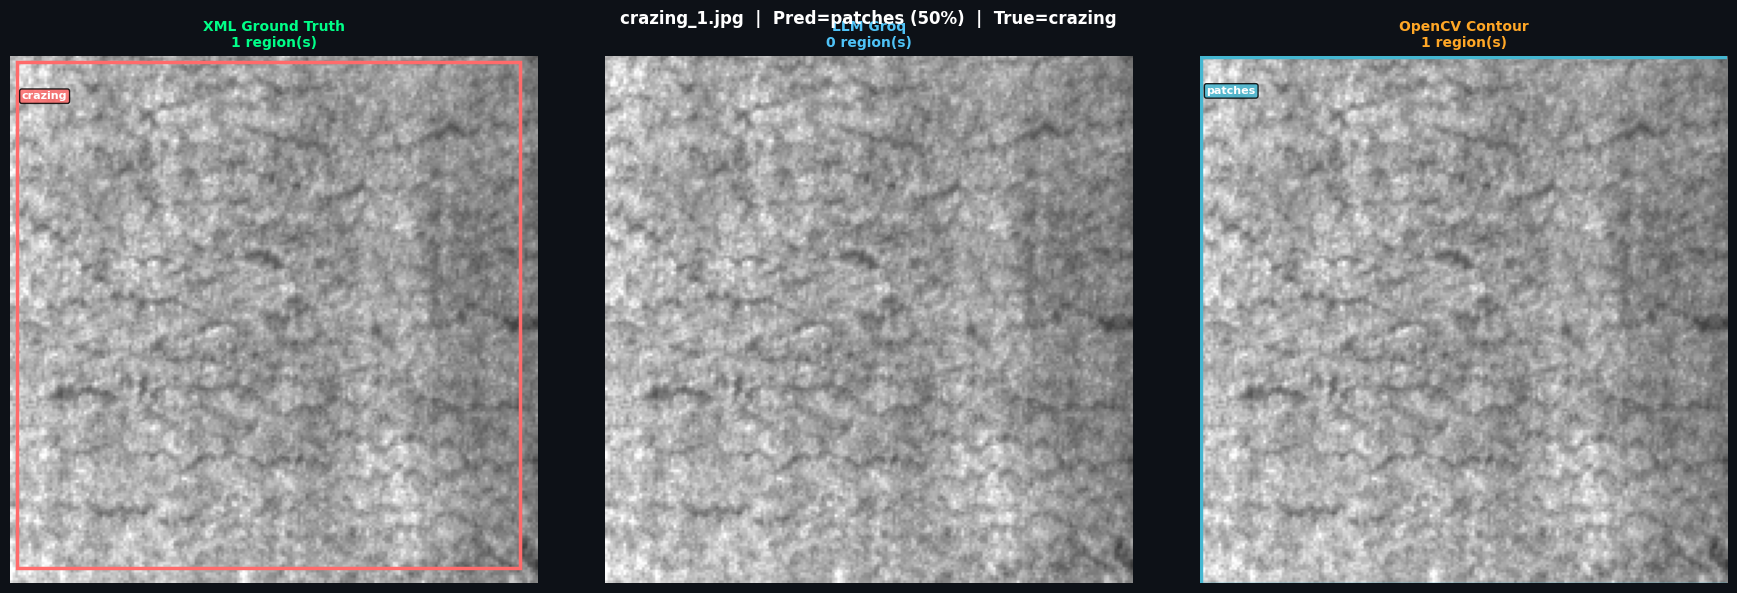


File: inclusion_1.jpg  |  Pred: crazing (99%) via WEIGHTED-Ensemble(1/1votes,w=0.9)  |  Area: xml_annotation  |  Regions: 4
Result: WRONG (true=inclusion)
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_inclusion_1.jpg.png


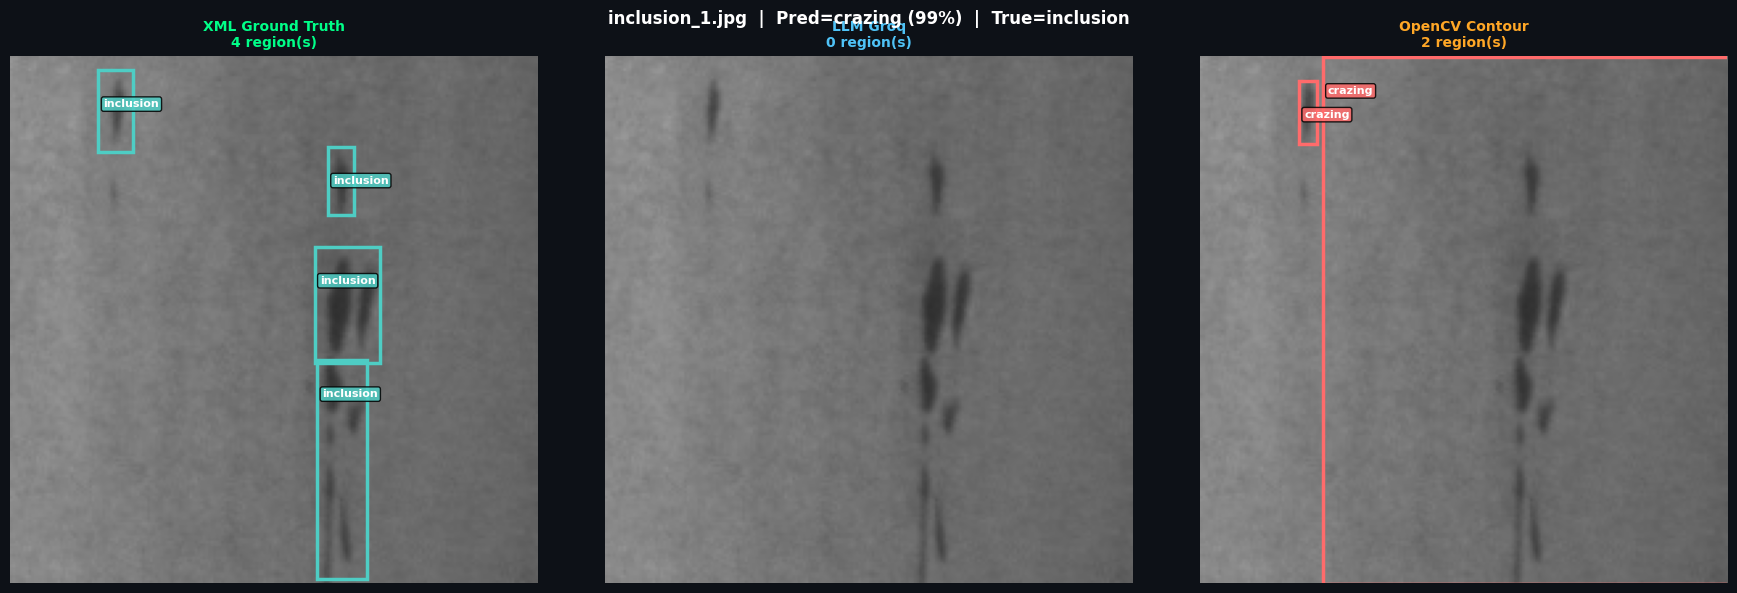


File: patches_1.jpg  |  Pred: patches (50%) via Default  |  Area: xml_annotation  |  Regions: 3
Result: CORRECT
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_patches_1.jpg.png


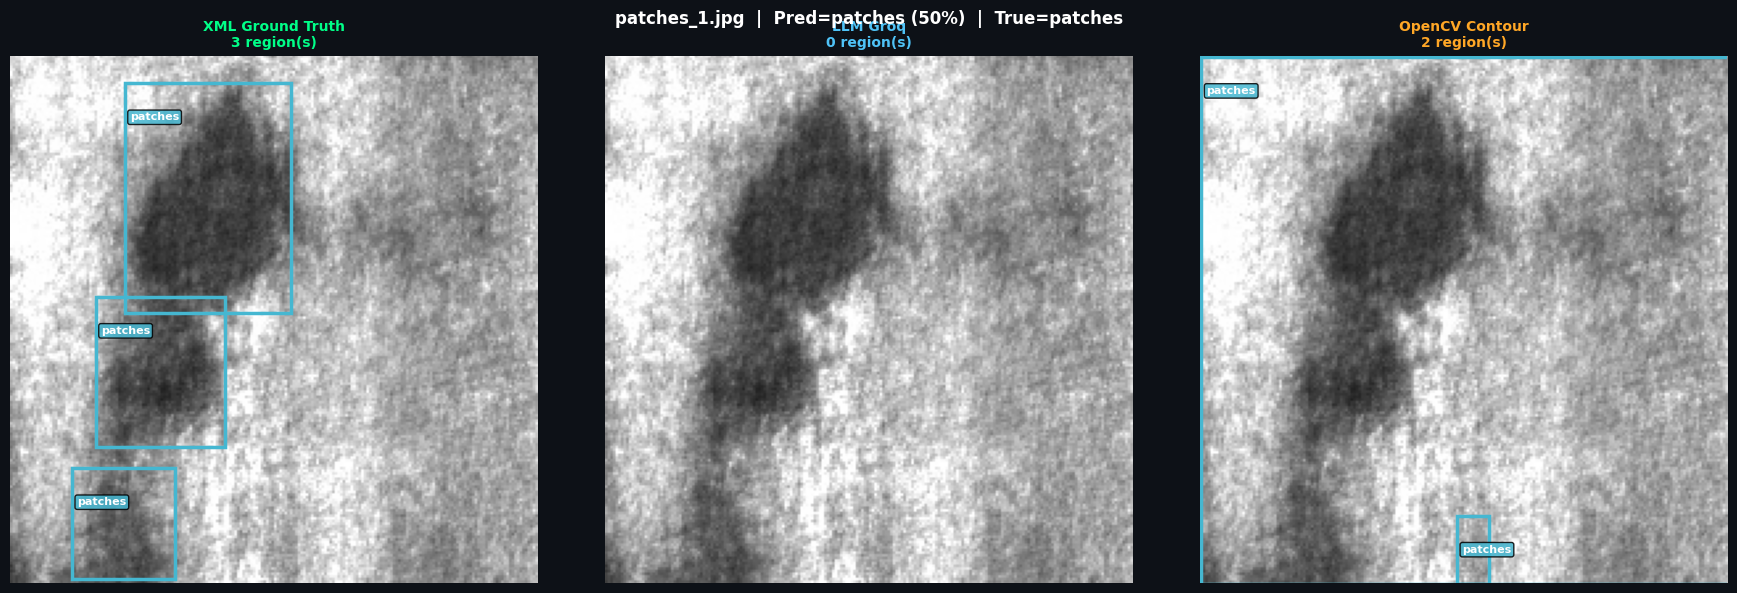


File: pitted_surface_1.jpg  |  Pred: patches (99%) via WEIGHTED-Ensemble(1/1votes,w=0.9)  |  Area: xml_annotation  |  Regions: 2
Result: WRONG (true=pitted_surface)
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_pitted_surface_1.jpg.png


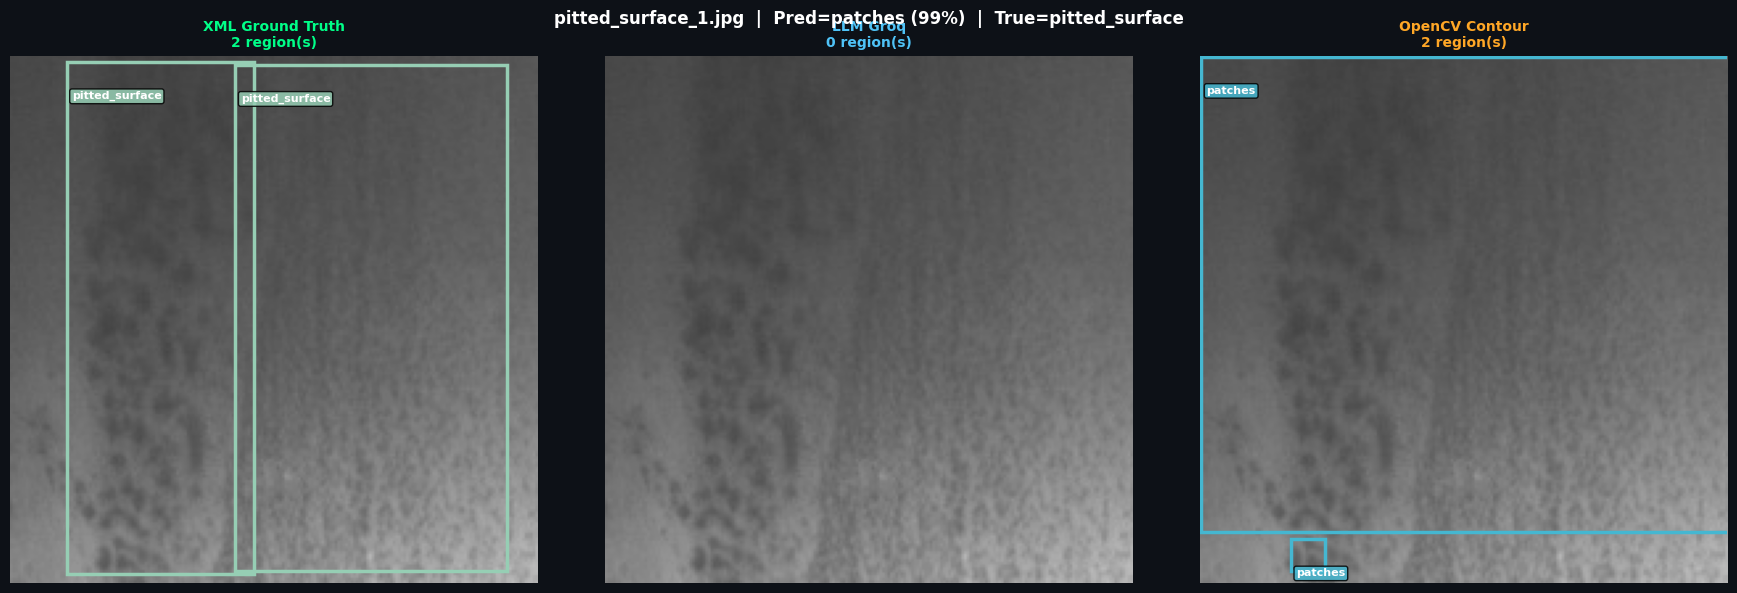


File: rolled-in_scale_1.jpg  |  Pred: patches (50%) via Default  |  Area: xml_annotation  |  Regions: 2
Result: WRONG (true=rolled-in_scale)
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_rolled-in_scale_1.jpg.png


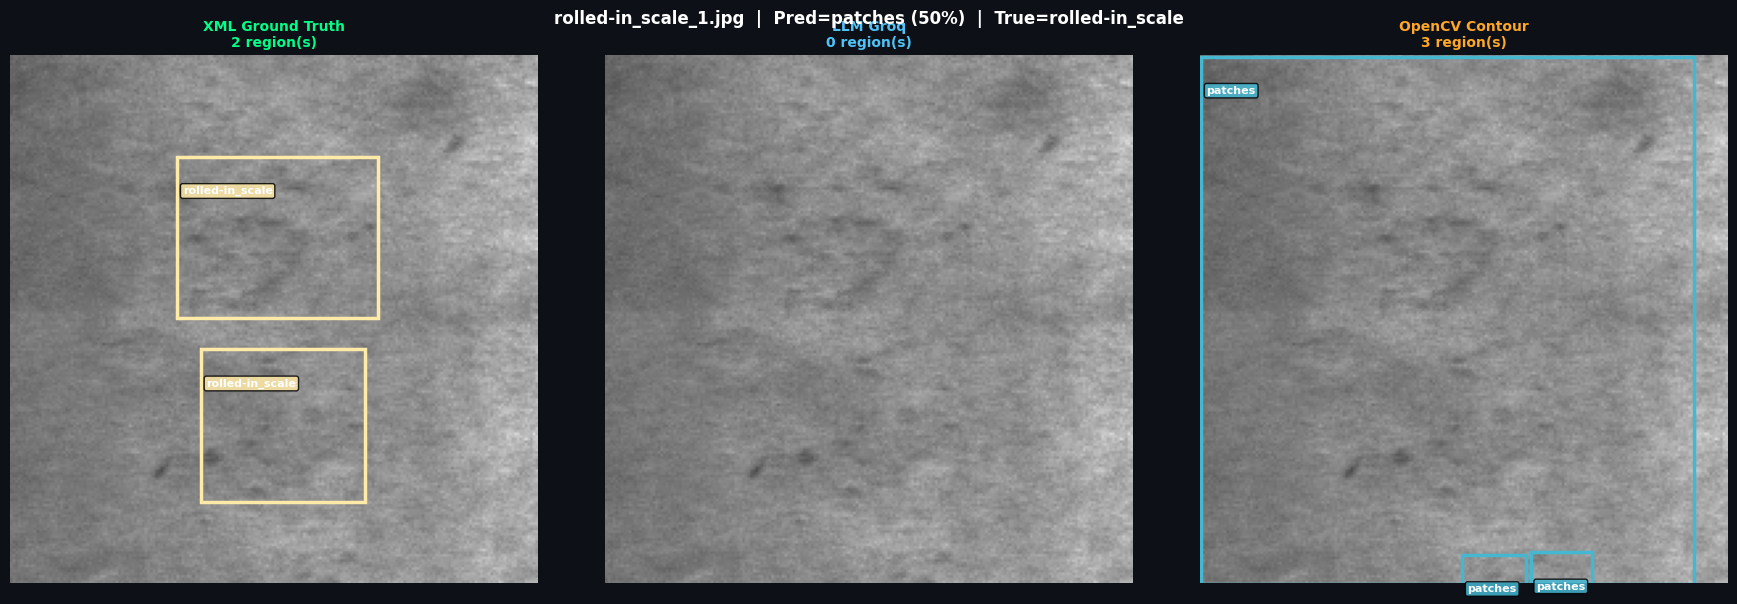


File: scratches_1.jpg  |  Pred: patches (99%) via WEIGHTED-Ensemble(1/1votes,w=0.9)  |  Area: xml_annotation  |  Regions: 2
Result: WRONG (true=scratches)
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\OUTPUT\DEMO_scratches_1.jpg.png


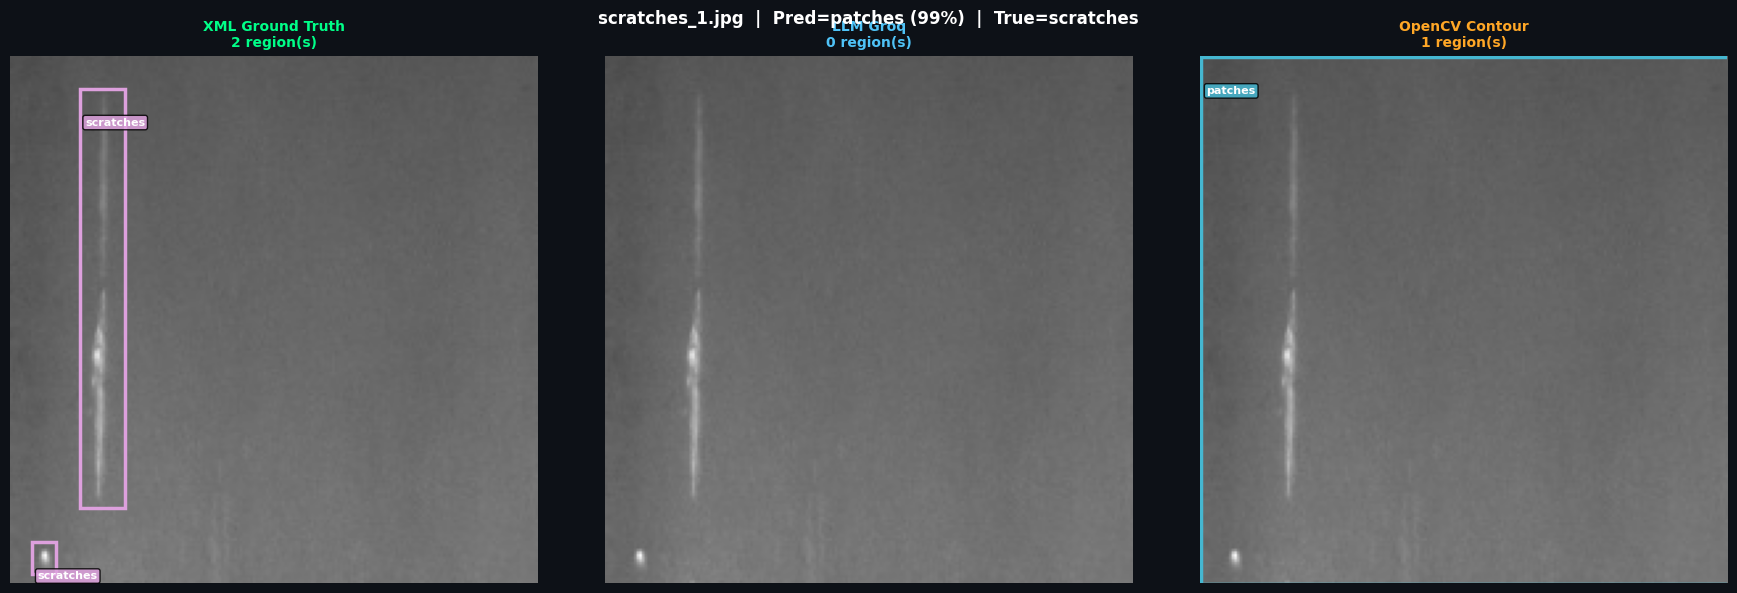

In [ ]:
# ================================================================
# CELL 13 — SINGLE IMAGE DEMO (one per class, side-by-side)
# ================================================================

def demo_image(img_path, true_label=None):
    fname = os.path.basename(img_path)
    f, img_res = extract_rich_features(img_path, IMG_SIZE)
    if f is None:
        print('Cannot load image.'); return
    pred,conf,meth = classify_defect_ensemble(f)
    regions,area_m = detect_areas(f,img_res,pred,fname,img_size=IMG_SIZE,use_llm=True)
    print(f'File: {fname}  |  Pred: {pred} ({conf:.0%}) via {meth}  |  '
          f'Area: {area_m}  |  Regions: {len(regions)}')
    if true_label:
        ok = 'CORRECT' if pred==true_label else f'WRONG (true={true_label})'
        print(f'Result: {ok}')

    xml_reg = load_xml_annotations(fname,(IMG_SIZE,IMG_SIZE))
    llm_reg = None
    if groq_client:
        ap=_build_area_prompt(f,pred,IMG_SIZE)
        r=_call_groq_model(ap, GROQ_MODELS[0], max_tokens=300)
        if r: llm_reg=_parse_bbox_json(r,IMG_SIZE,pred)
    ctr_reg = contour_regions(img_res, pred, IMG_SIZE)

    sources=[('XML Ground Truth',xml_reg or [],'#00FF88'),
             ('LLM Groq',        llm_reg or [],'#4FC3F7'),
             ('OpenCV Contour',  ctr_reg or [],'#FFA726')]

    fig,axes=plt.subplots(1,3,figsize=(18,6))
    fig.patch.set_facecolor('#0d1117')
    for ax,(title,regs,tcol) in zip(axes,sources):
        ax.imshow(img_res); ax.set_facecolor('#1c1c2e')
        for r in regs:
            x,y,bw,bh=r['bbox']; lbl=r.get('label',pred)
            color=DEFECT_COLORS.get(lbl,'#FF4444')
            ax.add_patch(Rectangle((x,y),bw,bh,linewidth=2.5,edgecolor=color,facecolor='none'))
            ax.text(x+2,y+14,lbl,fontsize=8,color='white',fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',facecolor=color,alpha=0.85))
        ax.set_title(f'{title}\n{len(regs)} region(s)',
                     color=tcol,fontweight='bold',fontsize=10)
        ax.axis('off')
    plt.suptitle(f'{fname}  |  Pred={pred} ({conf:.0%})  |  True={true_label or "?"}',
                 fontsize=12,fontweight='bold',color='white')
    plt.tight_layout()
    sp=os.path.join(OUTPUT_DIR,f'DEMO_{fname}.png')
    plt.savefig(sp,dpi=150,bbox_inches='tight',facecolor='#0d1117')
    print(f'Saved: {sp}'); plt.show()


print('Running demos for each defect class...\n')
for cls in CLASS_NAMES:
    cls_dir=os.path.join(IMAGES_DIR,cls)
    if os.path.isdir(cls_dir):
        fname=sorted(os.listdir(cls_dir))[0]
        demo_image(os.path.join(cls_dir,fname),true_label=cls)
        print()